# International Football Analysis (1872–2024)

**Task 2.1**

This report uses `results.csv`, `goalscorers.csv`, and `shootouts.csv`
to examine historical leaders, team efficiency, penalty-shootout drama,
failures after scoring first, and changes between football eras.

### Main findings

- England scored the most team goals in the results data: **2,350**.
- Cristiano Ronaldo leads the supplied goalscorer data with **113**
  non-own goals through 2024.
- With a 100-match minimum, Brazil leads points per match (**2.111**);
  Jersey leads goals per match (**2.754**), showing why team context matters.
- The 2010s had the most shootouts (**153**); friendlies had the largest
  raw tournament count (**79**), while the COSAFA Cup had 63.
- Brazil most often scored first and failed to win (**57 matches**), but
  this is partly explained by its large number of matches and opening goals.
- Goals and winning margins generally decreased over time: goals per match
  fell from **5.58 in the 1880s** to **2.68 in 2020–2024**.


## 1. Setup and data loading

The analysis is limited to matches dated on or before 31 December 2024.
The three files have different row meanings, so they are joined using
`date`, `home_team`, and `away_team`; team-level home and away records are
concatenated where appropriate.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

DATA_DIR = Path("data")
CUTOFF = pd.Timestamp("2024-12-31")
MIN_MATCHES = 100
MATCH_KEYS = ["date", "home_team", "away_team"]


In [2]:
results_raw = pd.read_csv(DATA_DIR / "results.csv")
goals_raw = pd.read_csv(DATA_DIR / "goalscorers.csv")
shootouts_raw = pd.read_csv(DATA_DIR / "shootouts.csv")

for frame in (results_raw, goals_raw, shootouts_raw):
    frame["date"] = pd.to_datetime(frame["date"], errors="coerce")

audit = pd.DataFrame(
    {
        "rows": [len(results_raw), len(goals_raw), len(shootouts_raw)],
        "duplicate_rows": [
            results_raw.duplicated().sum(),
            goals_raw.duplicated().sum(),
            shootouts_raw.duplicated().sum(),
        ],
        "missing_values": [
            results_raw.isna().sum().sum(),
            goals_raw.isna().sum().sum(),
            shootouts_raw.isna().sum().sum(),
        ],
        "first_date": [
            results_raw["date"].min(),
            goals_raw["date"].min(),
            shootouts_raw["date"].min(),
        ],
        "last_date": [
            results_raw["date"].max(),
            goals_raw["date"].max(),
            shootouts_raw["date"].max(),
        ],
    },
    index=["results", "goalscorers", "shootouts"],
)
audit


,rows,duplicate_rows,missing_values,first_date,last_date
results,49520,0,4,1872-11-30,2026-07-19
goalscorers,47903,79,298,1916-07-02,2026-07-15
shootouts,683,0,423,1967-08-22,2026-07-07


### Cleaning decisions

- Invalid dates and result rows without scores are removed.
- Rows after 2024 are excluded to match the assignment period.
- Team and player text fields are stripped of surrounding spaces.
- Repeated scorer rows are **not** automatically deleted: one player can
  score several goals in a match, including at an unknown minute.
- Own goals remain valid match events but are excluded from player scoring
  totals.


In [3]:
results = results_raw.loc[results_raw["date"].notna() & (results_raw["date"] <= CUTOFF)].copy()
goals = goals_raw.loc[goals_raw["date"].notna() & (goals_raw["date"] <= CUTOFF)].copy()
shootouts = shootouts_raw.loc[
    shootouts_raw["date"].notna() & (shootouts_raw["date"] <= CUTOFF)
].copy()

for frame in (results, goals, shootouts):
    for column in frame.columns:
        if pd.api.types.is_string_dtype(frame[column]):
            frame[column] = frame[column].str.strip()

results["home_score"] = pd.to_numeric(results["home_score"], errors="coerce")
results["away_score"] = pd.to_numeric(results["away_score"], errors="coerce")
results = results.dropna(subset=["home_score", "away_score"]).copy()
results[["home_score", "away_score"]] = results[["home_score", "away_score"]].astype(int)
goals["minute"] = pd.to_numeric(goals["minute"], errors="coerce")

pd.DataFrame(
    {
        "clean_rows": [len(results), len(goals), len(shootouts)],
        "unique_matches": [
            results[MATCH_KEYS].drop_duplicates().shape[0],
            goals[MATCH_KEYS].drop_duplicates().shape[0],
            shootouts[MATCH_KEYS].drop_duplicates().shape[0],
        ],
    },
    index=["results", "goalscorers", "shootouts"],
)


,clean_rows,unique_matches
results,48095,48094
goalscorers,45843,14871
shootouts,648,648


## 2. Feature engineering and descriptive statistics


In [4]:
results["decade"] = (results["date"].dt.year // 10) * 10
results["total_goals"] = results["home_score"] + results["away_score"]
results["goal_margin"] = (results["home_score"] - results["away_score"]).abs()
results["is_draw"] = results["home_score"].eq(results["away_score"])

results["winner"] = np.select(
    [
        results["home_score"] > results["away_score"],
        results["away_score"] > results["home_score"],
    ],
    [results["home_team"], results["away_team"]],
    default="Draw",
)

# One pair (Tahiti–New Caledonia, 1974-02-17) played twice on the same
# date. Neither row appears in the event files. Keep both for result
# analysis, but use one row per key for safe event-file linkage.
result_links = results.drop_duplicates(MATCH_KEYS).copy()

home = pd.DataFrame(
    {
        "team": results["home_team"],
        "opponent": results["away_team"],
        "goals_for": results["home_score"],
        "goals_against": results["away_score"],
        "points": np.select(
            [
                results["home_score"] > results["away_score"],
                results["home_score"] == results["away_score"],
            ],
            [3, 1],
            default=0,
        ),
    }
)

away = pd.DataFrame(
    {
        "team": results["away_team"],
        "opponent": results["home_team"],
        "goals_for": results["away_score"],
        "goals_against": results["home_score"],
        "points": np.select(
            [
                results["away_score"] > results["home_score"],
                results["away_score"] == results["home_score"],
            ],
            [3, 1],
            default=0,
        ),
    }
)

# Concatenate the home and away perspectives into one team-match table.
team_matches = pd.concat([home, away], ignore_index=True)
team_summary = (
    team_matches.groupby("team", as_index=False)
    .agg(
        matches=("team", "size"),
        goals=("goals_for", "sum"),
        goals_against=("goals_against", "sum"),
        points=("points", "sum"),
    )
)
team_summary["points_per_match"] = team_summary["points"] / team_summary["matches"]
team_summary["goals_per_match"] = team_summary["goals"] / team_summary["matches"]

match_description = results[
    ["home_score", "away_score", "total_goals", "goal_margin"]
].describe().round(2)
team_description = team_summary[
    ["matches", "goals", "points", "points_per_match", "goals_per_match"]
].describe().round(2)

display(match_description)
display(team_description)


,home_score,away_score,total_goals,goal_margin
count,48095.00,48095.00,48095.00,48095.00
mean,1.76,1.18,2.94,1.72
std,1.78,1.40,2.10,1.80
min,0.00,0.00,0.00,0.00
25%,1.00,0.00,1.00,1.00
50%,1.00,1.00,3.00,1.00
75%,2.00,2.00,4.00,2.00
max,31.00,21.00,31.00,31.00


,matches,goals,points,points_per_match,goals_per_match
count,335.00,335.00,335.00,335.00,335.00
mean,287.13,422.38,398.05,1.21,1.49
std,284.81,488.99,468.91,0.54,0.75
min,1.00,0.00,0.00,0.00,0.00
25%,25.50,43.00,24.00,0.89,1.05
50%,220.00,235.00,223.00,1.25,1.38
75%,481.50,656.00,640.50,1.56,1.77
max,1087.00,2350.00,2206.00,3.00,8.00


## 3. Top performers


In [5]:
top_team_goals = (
    team_summary.sort_values(["goals", "matches"], ascending=False)
    .head(10)
    [["team", "matches", "goals", "goals_per_match"]]
    .reset_index(drop=True)
)

own_goal = goals["own_goal"].astype(str).str.upper().eq("TRUE")
top_scorers = (
    goals.loc[goals["scorer"].notna() & ~own_goal]
    .groupby("scorer")
    .size()
    .rename("goals")
    .reset_index()
    .sort_values(["goals", "scorer"], ascending=[False, True])
    .head(10)
    .reset_index(drop=True)
)

display(top_team_goals)
display(top_scorers)


,team,matches,goals,goals_per_match
0,England,1076,2350,2.184015
1,Germany,1017,2286,2.247788
2,Brazil,1045,2276,2.177990
3,Sweden,1087,2147,1.975161
4,Argentina,1056,1997,1.891098
5,Hungary,992,1991,2.007056
6,Netherlands,865,1804,2.085549
7,South Korea,993,1769,1.781470
8,Mexico,979,1731,1.768131
9,France,921,1682,1.826276


,scorer,goals
0,Cristiano Ronaldo,113
1,Robert Lewandowski,64
2,Harry Kane,61
3,Lionel Messi,61
4,Romelu Lukaku,60
5,Edin Džeko,52
6,Ali Daei,49
7,Aleksandar Mitrović,48
8,Miroslav Klose,48
9,Carlos Ruiz,47


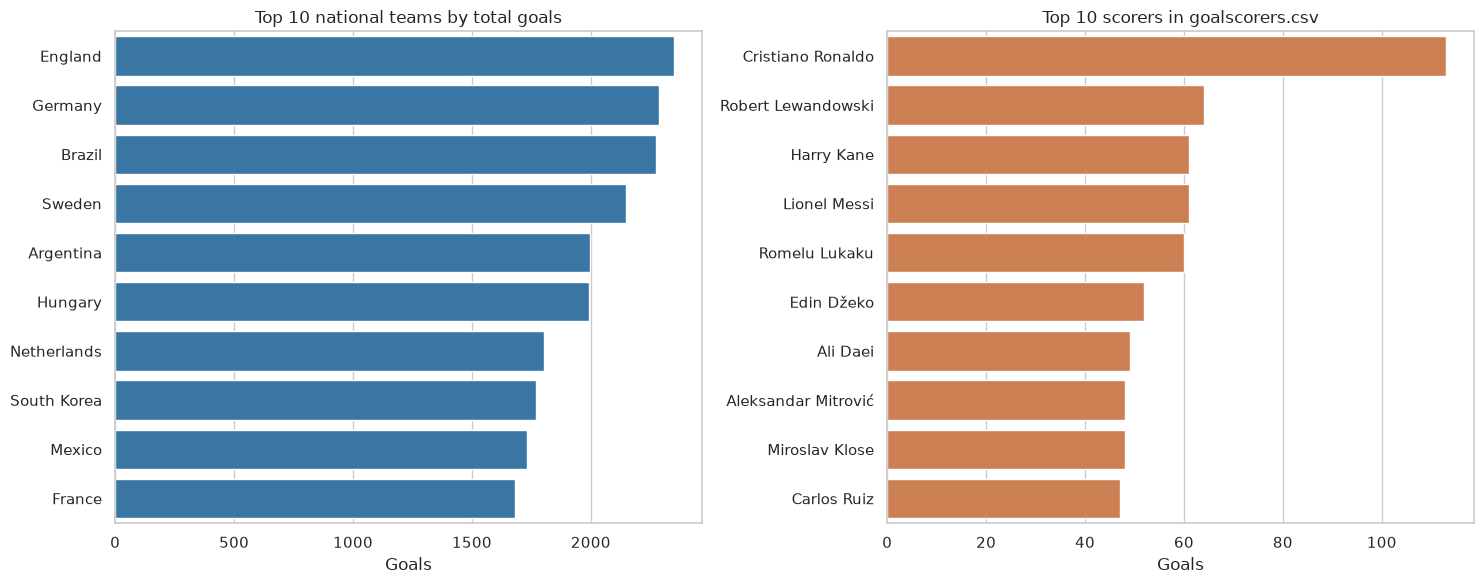

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=top_team_goals,
    x="goals",
    y="team",
    ax=axes[0],
    color="#2878B5",
)
axes[0].set_title("Top 10 national teams by total goals")
axes[0].set(xlabel="Goals", ylabel="")

sns.barplot(
    data=top_scorers,
    x="goals",
    y="scorer",
    ax=axes[1],
    color="#E07A3F",
)
axes[1].set_title("Top 10 scorers in goalscorers.csv")
axes[1].set(xlabel="Goals", ylabel="")

plt.tight_layout()
plt.show()


**Finding:** England, Germany, and Brazil lead team scoring volume.
Cristiano Ronaldo leads the supplied scorer file. These player totals
describe the provided event file; they should not be treated as complete
official career records because the file does not cover every match in
`results.csv`.


## 4. Team efficiency


In [7]:
eligible = team_summary.loc[team_summary["matches"] >= MIN_MATCHES].copy()

top_points_efficiency = (
    eligible.sort_values(["points_per_match", "matches"], ascending=False)
    .head(10)
    [["team", "matches", "points", "points_per_match"]]
    .reset_index(drop=True)
)
top_goals_efficiency = (
    eligible.sort_values(["goals_per_match", "matches"], ascending=False)
    .head(10)
    [["team", "matches", "goals", "goals_per_match"]]
    .reset_index(drop=True)
)

display(top_points_efficiency.round(3))
display(top_goals_efficiency.round(3))


,team,matches,points,points_per_match
0,Brazil,1045,2206,2.111
1,Jersey,232,475,2.047
2,Spain,769,1535,1.996
3,England,1076,2099,1.951
4,Iran,600,1170,1.950
5,Germany,1017,1979,1.946
6,Guernsey,240,460,1.917
7,Argentina,1056,1999,1.893
8,Italy,879,1645,1.871
9,South Korea,993,1839,1.852


,team,matches,goals,goals_per_match
0,Jersey,232,639,2.754
1,Tahiti,241,657,2.726
2,New Caledonia,261,693,2.655
3,Guernsey,240,616,2.567
4,Fiji,262,607,2.317
5,Germany,1017,2286,2.248
6,England,1076,2350,2.184
7,Brazil,1045,2276,2.178
8,Papua New Guinea,152,331,2.178
9,Solomon Islands,210,457,2.176


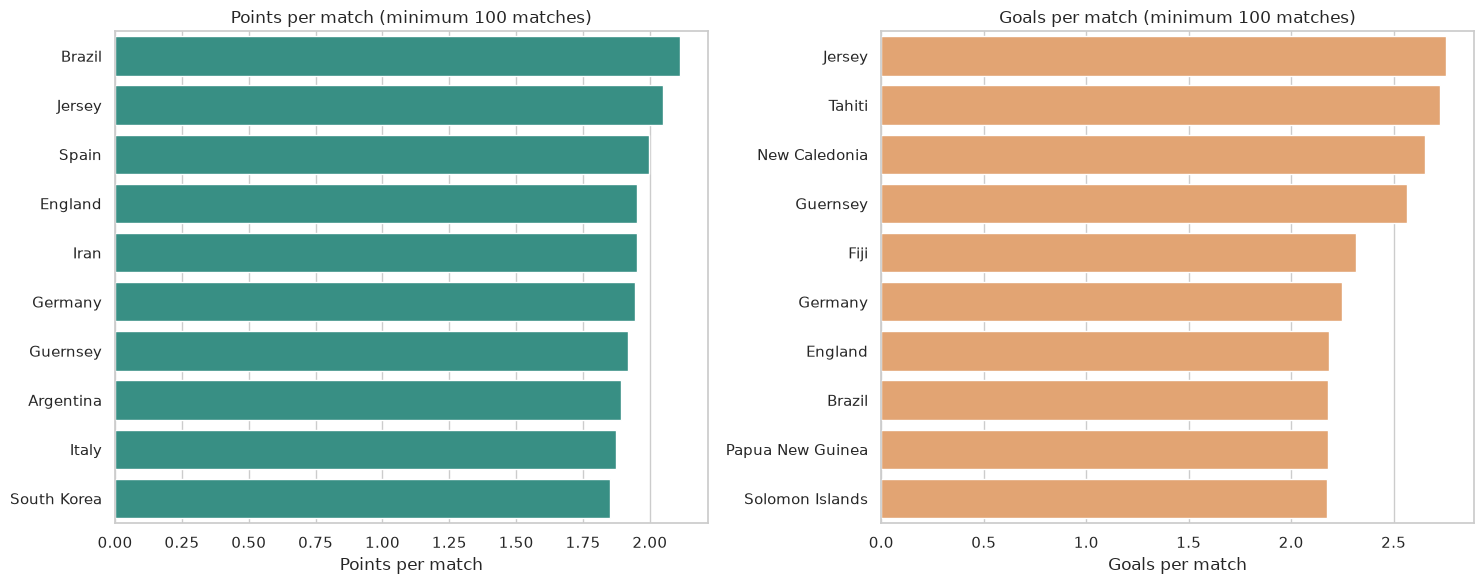

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=top_points_efficiency,
    x="points_per_match",
    y="team",
    ax=axes[0],
    color="#2A9D8F",
)
axes[0].set_title(f"Points per match (minimum {MIN_MATCHES} matches)")
axes[0].set(xlabel="Points per match", ylabel="")

sns.barplot(
    data=top_goals_efficiency,
    x="goals_per_match",
    y="team",
    ax=axes[1],
    color="#F4A261",
)
axes[1].set_title(f"Goals per match (minimum {MIN_MATCHES} matches)")
axes[1].set(xlabel="Goals per match", ylabel="")

plt.tight_layout()
plt.show()


**Finding:** Brazil has the best points-per-match value after the
100-match filter. Jersey has the highest goals per match, while Tahiti,
New Caledonia, and Guernsey also rank very highly.

They do not all belong in a simple “best national team” comparison.
Jersey and Guernsey are non-FIFA representative teams, and teams play
different opponents and competition schedules. The threshold removes
tiny samples but does not adjust for opponent strength.


## 5. Drama analysis: penalty shootouts


In [9]:
# Merge shootouts with results so each shootout receives its tournament.
shootout_matches = shootouts.merge(
    result_links[MATCH_KEYS + ["tournament"]],
    on=MATCH_KEYS,
    how="left",
    validate="many_to_one",
)
shootout_matches["decade"] = (shootout_matches["date"].dt.year // 10) * 10

shootouts_by_decade = (
    shootout_matches.groupby("decade")
    .size()
    .rename("shootouts")
    .reset_index()
)
shootouts_by_tournament = (
    shootout_matches.dropna(subset=["tournament"])
    .groupby("tournament")
    .size()
    .rename("shootouts")
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

display(shootouts_by_decade)
display(shootouts_by_tournament)
print("Shootouts without a matching result:", shootout_matches["tournament"].isna().sum())


,decade,shootouts
0,1960,1
1,1970,38
2,1980,97
3,1990,126
4,2000,144
5,2010,153
6,2020,89


,tournament,shootouts
0,Friendly,79
1,COSAFA Cup,63
2,African Cup of Nations,44
3,FIFA World Cup,35
4,Copa América,33
5,African Cup of Nations qualification,28
6,AFC Asian Cup,27
7,UEFA Euro,25
8,CONIFA World Football Cup,17
9,King's Cup,16


Shootouts without a matching result: 1


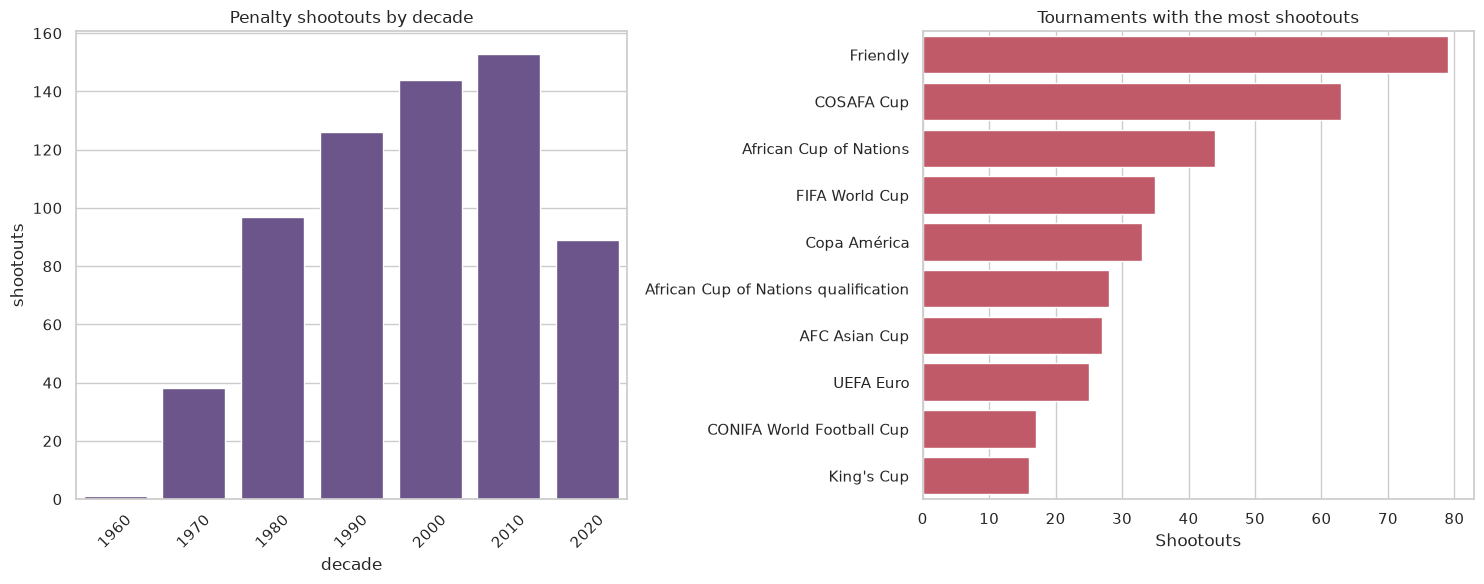

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=shootouts_by_decade,
    x="decade",
    y="shootouts",
    ax=axes[0],
    color="#6A4C93",
)
axes[0].set_title("Penalty shootouts by decade")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=shootouts_by_tournament,
    x="shootouts",
    y="tournament",
    ax=axes[1],
    color="#D1495B",
)
axes[1].set_title("Tournaments with the most shootouts")
axes[1].set(xlabel="Shootouts", ylabel="")

plt.tight_layout()
plt.show()


**Finding:** The 2010s produced the most shootouts (153). The 2020s are
incomplete because the data stops in 2024. By raw count, friendlies lead
with 79, followed by the COSAFA Cup with 63 and the African Cup of Nations
with 44. Raw counts reflect both tournament format and how many matches
each competition contributes.


## 6. Worst performers after scoring first


In [11]:
# Merge scoring events with final results.
goal_matches = goals.merge(
    result_links[MATCH_KEYS + ["home_score", "away_score"]],
    on=MATCH_KEYS,
    how="inner",
    validate="many_to_one",
)

# If any goal time is missing, the true first goal may be unknown.
complete_time_keys = (
    goal_matches.groupby(MATCH_KEYS)["minute"]
    .apply(lambda values: values.notna().all())
    .rename("complete_times")
    .reset_index()
)
goal_matches = goal_matches.merge(complete_time_keys, on=MATCH_KEYS)
timed_goals = goal_matches.loc[goal_matches["complete_times"]].copy()

timed_goals["first_minute"] = timed_goals.groupby(MATCH_KEYS)["minute"].transform("min")
first_events = timed_goals.loc[timed_goals["minute"].eq(timed_goals["first_minute"])].copy()

# Exclude the rare case where opposing teams have events at the same earliest minute.
unambiguous_keys = (
    first_events.groupby(MATCH_KEYS)["team"]
    .nunique()
    .eq(1)
    .rename("one_first_team")
    .reset_index()
)
first_events = first_events.merge(unambiguous_keys, on=MATCH_KEYS)
first_events = first_events.loc[first_events["one_first_team"]]

first_scorers = (
    first_events.drop_duplicates(MATCH_KEYS)
    .rename(columns={"team": "first_team"})
    [MATCH_KEYS + ["first_team", "home_score", "away_score"]]
)

first_scorers["won"] = (
    first_scorers["first_team"].eq(first_scorers["home_team"])
    & first_scorers["home_score"].gt(first_scorers["away_score"])
) | (
    first_scorers["first_team"].eq(first_scorers["away_team"])
    & first_scorers["away_score"].gt(first_scorers["home_score"])
)
first_scorers["failed_to_win"] = ~first_scorers["won"]

lead_summary = (
    first_scorers.groupby("first_team", as_index=False)
    .agg(
        scored_first=("first_team", "size"),
        failed_to_win=("failed_to_win", "sum"),
    )
    .rename(columns={"first_team": "team"})
)
lead_summary["failure_rate"] = (
    100 * lead_summary["failed_to_win"] / lead_summary["scored_first"]
)

worst_after_scoring_first = (
    lead_summary.sort_values(["failed_to_win", "scored_first"], ascending=False)
    .head(10)
    .reset_index(drop=True)
)
worst_after_scoring_first.round(1)


,team,scored_first,failed_to_win,failure_rate
0,Brazil,323,57,17.6
1,Uruguay,265,52,19.6
2,Switzerland,181,52,28.7
3,Sweden,210,50,23.8
4,Republic of Ireland,161,49,30.4
5,Denmark,194,48,24.7
6,Paraguay,168,47,28.0
7,Mexico,261,46,17.6
8,Belgium,222,46,20.7
9,Poland,177,46,26.0


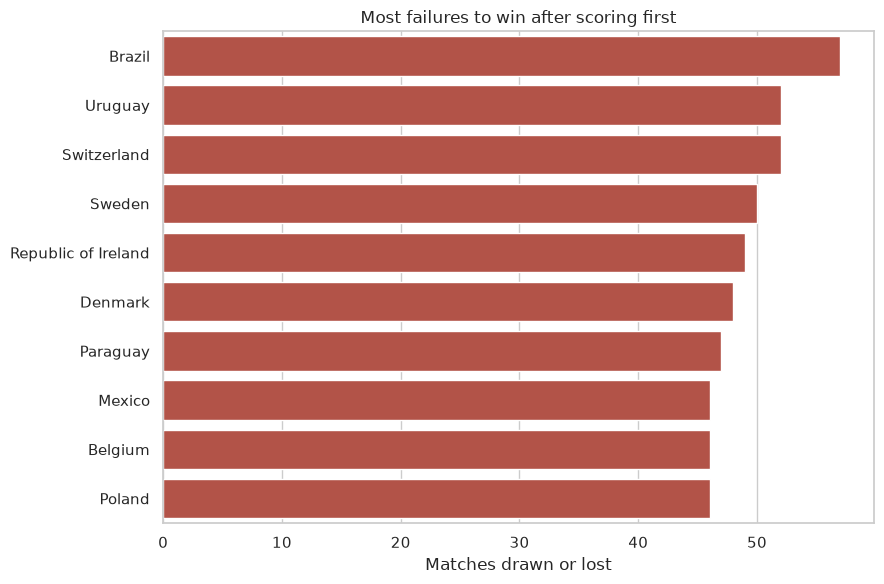

In [12]:
plt.figure(figsize=(9, 6))
sns.barplot(
    data=worst_after_scoring_first,
    x="failed_to_win",
    y="team",
    color="#C44536",
)
plt.title("Most failures to win after scoring first")
plt.xlabel("Matches drawn or lost")
plt.ylabel("")
plt.tight_layout()
plt.show()


**Finding:** Brazil has the largest raw count (57), followed by
Switzerland and Uruguay (52 each). Count is not the same as fragility:
Brazil failed in only 17.6% of its 323 recorded opening-goal matches,
whereas several teams in the table have higher rates. The result is
limited to matches covered by `goalscorers.csv`.


## 7. Era comparison


In [13]:
era_summary = (
    results.groupby("decade", as_index=False)
    .agg(
        matches=("date", "size"),
        goals_per_match=("total_goals", "mean"),
        draw_rate=("is_draw", "mean"),
    )
)

winning_margins = (
    results.loc[~results["is_draw"]]
    .groupby("decade")["goal_margin"]
    .mean()
    .rename("average_winning_margin")
    .reset_index()
)
era_summary = era_summary.merge(winning_margins, on="decade", how="left")
era_summary["draw_rate"] *= 100
era_summary.round(2)


,decade,matches,goals_per_match,draw_rate,average_winning_margin
0,1870,13,4.54,15.38,3.00
1,1880,55,5.58,9.09,4.22
2,1890,59,5.15,15.25,3.64
3,1900,138,4.16,17.39,2.77
4,1910,330,4.22,16.06,2.78
5,1920,831,3.88,17.93,2.52
6,1930,1079,4.32,15.94,2.49
7,1940,833,4.34,15.37,2.85
8,1950,1651,4.00,18.35,2.47
9,1960,2971,3.48,19.62,2.38


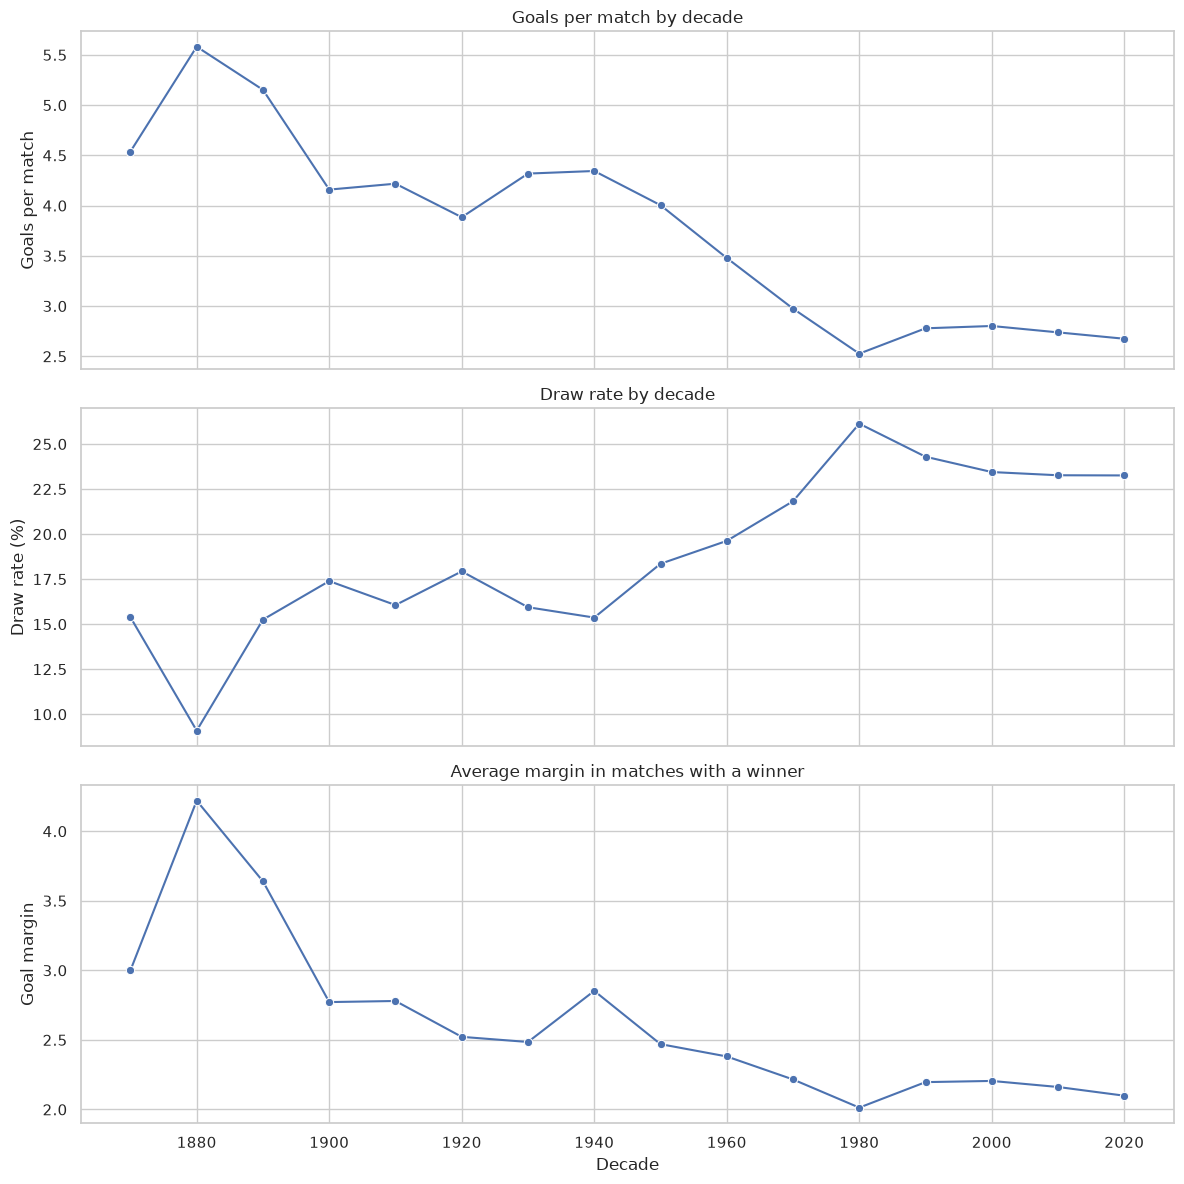

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

sns.lineplot(data=era_summary, x="decade", y="goals_per_match", marker="o", ax=axes[0])
axes[0].set_title("Goals per match by decade")
axes[0].set_ylabel("Goals per match")

sns.lineplot(data=era_summary, x="decade", y="draw_rate", marker="o", ax=axes[1])
axes[1].set_title("Draw rate by decade")
axes[1].set_ylabel("Draw rate (%)")

sns.lineplot(
    data=era_summary,
    x="decade",
    y="average_winning_margin",
    marker="o",
    ax=axes[2],
)
axes[2].set_title("Average margin in matches with a winner")
axes[2].set_ylabel("Goal margin")
axes[2].set_xlabel("Decade")

plt.tight_layout()
plt.show()


**Finding:** Early international football was much higher-scoring and
more uneven. The 1880s averaged 5.58 goals per match and a 4.22-goal
winning margin. The 1980s averaged only 2.53 goals and had the highest
draw rate (26.1%). From 2020 through 2024, matches averaged 2.68 goals
with an average winning margin of 2.10.


## 8. Outlier detection and handling


IQR upper fence: 3.5 goals
Flagged matches: 5,838 (12.1%)


,date,home_team,away_team,home_score,away_score,goal_margin,tournament
25425,2001-04-11,Australia,American Samoa,31,0,31,FIFA World Cup qualification
8551,1971-09-13,Tahiti,Cook Islands,30,0,30,South Pacific Games
11916,1979-08-30,Fiji,Kiribati,24,0,24,South Pacific Games
25422,2001-04-09,Australia,Tonga,22,0,22,FIFA World Cup qualification
37064,2013-06-24,Provence,Tibet,22,0,22,"International Tournament of Peoples, Cultures ..."
6580,1966-04-03,Libya,Oman,21,0,21,Arab Cup
29045,2005-03-11,Guam,North Korea,0,21,21,EAFF Championship
37062,2013-06-23,Quebec,Tibet,21,0,21,"International Tournament of Peoples, Cultures ..."
30521,2006-11-24,Sápmi,Monaco,21,1,20,Viva World Cup
15922,1987-12-15,American Samoa,Papua New Guinea,0,20,20,South Pacific Games


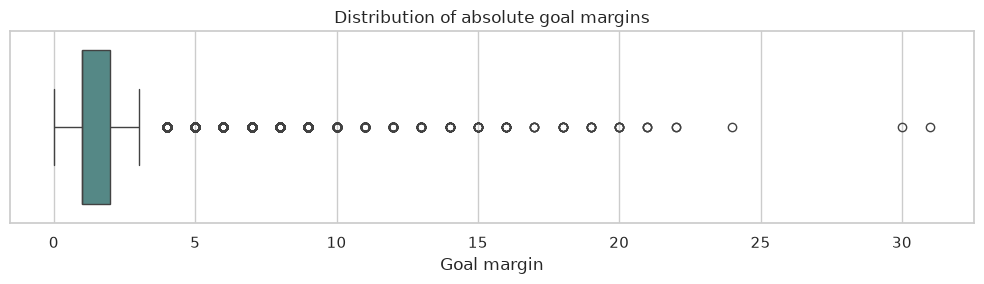

In [15]:
q1 = results["goal_margin"].quantile(0.25)
q3 = results["goal_margin"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

result_outliers = results.loc[results["goal_margin"] > upper_fence].copy()
most_lopsided = (
    results.sort_values(["goal_margin", "total_goals"], ascending=False)
    .head(10)
    [[
        "date", "home_team", "away_team", "home_score", "away_score",
        "goal_margin", "tournament"
    ]]
)

print(f"IQR upper fence: {upper_fence:.1f} goals")
print(f"Flagged matches: {len(result_outliers):,} ({len(result_outliers) / len(results):.1%})")
display(most_lopsided)

plt.figure(figsize=(10, 3))
sns.boxplot(data=results, x="goal_margin", color="#4D908E")
plt.title("Distribution of absolute goal margins")
plt.xlabel("Goal margin")
plt.tight_layout()
plt.show()


**Finding and handling:** The most lopsided result is Australia's 31–0
win over American Samoa on 11 April 2001. The IQR rule flags margins of
four or more, but these are valid football results rather than obvious
data-entry errors. They are therefore retained for historical totals and
clearly flagged instead of deleted.


## 9. Conclusions and recommendations

1. **Historical dominance:** England leads total scoring, while Brazil
   leads points efficiency among teams with at least 100 matches.
2. **Use context in rankings:** A minimum-match threshold helps, but
   non-FIFA status, opponent strength, region, and era still affect the
   efficiency tables.
3. **Prepare for competition-specific shootouts:** The 2010s were the
   peak decade, and the COSAFA Cup is especially prominent after
   friendlies.
4. **Judge lead protection by both count and rate:** Brazil has the most
   failures after scoring first mainly because it has many opportunities.
5. **Football became tighter:** Goals and winning margins declined
   substantially from the early decades, while draw rates increased.

### Recommendations

- Add opponent-strength or Elo adjustment before using efficiency
  rankings for federation decisions.
- Compare both the number and percentage of failed leads.
- Track shootouts by tournament and knockout stage for coaching preparation.
- Use a more complete goal-event source before publishing official
  all-time player totals or lead-protection rankings.
